# **Proyecto 2 – Parte I (Salud Mental en Jóvenes)**

**Salud Mental en Jóvenes - Dataset Descripción:**

El conjunto de datos recopila información relacionada con hábitos digitales, bienestar psicológico y estilos de vida de adolescentes. Incluye variables asociadas al uso de redes sociales, calidad del sueño, actividad física, interacción social, niveles de estrés y ansiedad, con el objetivo de evaluar factores potencialmente relacionados con el riesgo de depresión.

Fuente Kaggle: [Salud Mental en Jóvenes](https://www.kaggle.com/datasets/alfonselcaudelfons/salud-mentan-en-jovenes)

Cada fila representa a un adolescente e incluye información demográfica, hábitos de uso de tecnología, indicadores de salud mental y variables relacionadas con su bienestar general.

**Variables principales**
- Edad
- Género
- Horas diarias de redes sociales
- Plataforma más utilizada
- Horas de sueño
- Tiempo de pantalla antes de dormir
- Rendimiento académico
- Actividad física
- Nivel de interacción social
- Nivel de estrés
- Nivel de ansiedad
- Riesgo de depresión (variable objetivo)

**Dimensiones del dataset**

El conjunto de datos contiene 2.500 registros y 12 variables, combinando variables numéricas y categóricas.

# **Análisis Exploratorio de Datos (EDA) Inicial**

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
sns.set_style("whitegrid")

**Carga y Exploración de Datos:**

Se cargó el conjunto de datos de salud mental en jóvenes para iniciar el análisis exploratorio. Esta etapa permite verificar que el archivo fue leído correctamente y que las variables se encuentran disponibles para su revisión posterior.

In [26]:
df = pd.read_csv('/content/drive/MyDrive/dataset_salud_mental_Alfons.csv')
# Mostrar primeras y últimas filas
print("nprimeras y últimas filas del DataFrame:")
display(df.head())
print()
display(df.tail())

nprimeras y últimas filas del DataFrame:


,edad,género,horas_diarias_redes_sociales,uso_plataforma,horas_sueño,tiempo_pantalla_antes_dormir,rendimiento_académico,actividad_física,nivel_interacción_social,nivel_estrés,nivel_ansiedad,riesgo_depresión
0,19,masculino,3.8,Instagram,6.5,1.7,2.77,1.2,bajo,6,6,medio
1,16,masculino,6.5,Other,5.8,0.6,2.57,0.2,medio,9,7,alto
2,17,femenino,2.9,Other,7.0,1.2,3.04,1.7,alto,3,2,bajo
3,19,femenino,7.9,TikTok,5.0,1.6,2.21,1.2,medio,10,8,medio
4,15,femenino,1.2,TikTok,8.8,0.9,3.61,1.9,alto,1,2,bajo


,edad,género,horas_diarias_redes_sociales,uso_plataforma,horas_sueño,tiempo_pantalla_antes_dormir,rendimiento_académico,actividad_física,nivel_interacción_social,nivel_estrés,nivel_ansiedad,riesgo_depresión
2495,17,masculino,3.7,Other,6.1,1.8,2.82,0.4,bajo,5,5,medio
2496,17,femenino,7.4,TikTok,4.0,2.6,2.32,1.4,medio,9,9,medio
2497,15,femenino,6.3,Both,5.0,1.6,2.35,1.2,alto,9,10,medio
2498,17,femenino,4.5,TikTok,6.7,1.9,2.90,0.4,medio,7,7,medio
2499,13,femenino,7.9,Instagram,4.4,1.8,2.42,0.5,alto,10,9,medio


La revisión de las primeras y últimas filas permitió comprobar que el dataset mantiene una estructura ordenada y coherente. Cada registro representa a un joven e incluye información sobre edad, género, uso de redes sociales, sueño, actividad física, estrés, ansiedad, interacción social y riesgo de depresión. No se observan columnas desplazadas ni errores visibles de carga.

**Dimensiones del Dataset**

In [27]:
print("\nNúmero de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


Número de filas: 2500
Número de columnas: 12


El conjunto de datos contiene 2.500 registros y 12 variables, lo que representa una base suficiente para realizar un análisis exploratorio y proyectar un problema de clasificación. El tamaño del dataset permite observar patrones generales sin trabajar con una muestra excesivamente pequeña.

**Tipos de Datos y Estructura Básica**

In [28]:
# Mostrar la información del DataFrame
print("\nInformación del DataFrame:")
print(df.info())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   edad                          2500 non-null   int64  
 1   género                        2500 non-null   object 
 2   horas_diarias_redes_sociales  2500 non-null   float64
 3   uso_plataforma                2500 non-null   object 
 4   horas_sueño                   2500 non-null   float64
 5   tiempo_pantalla_antes_dormir  2500 non-null   float64
 6   rendimiento_académico         2500 non-null   float64
 7   actividad_física              2500 non-null   float64
 8   nivel_interacción_social      2500 non-null   object 
 9   nivel_estrés                  2500 non-null   int64  
 10  nivel_ansiedad                2500 non-null   int64  
 11  riesgo_depresión              2500 non-null   object 
dtypes: float64(5), int64(3), object(4)

In [29]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
edad                              int64
género                           object
horas_diarias_redes_sociales    float64
uso_plataforma                   object
horas_sueño                     float64
tiempo_pantalla_antes_dormir    float64
rendimiento_académico           float64
actividad_física                float64
nivel_interacción_social         object
nivel_estrés                      int64
nivel_ansiedad                    int64
riesgo_depresión                 object
dtype: object


La revisión de la estructura del dataset muestra una combinación de variables numéricas y categóricas. Las variables numéricas permiten analizar hábitos y niveles de bienestar, mientras que las categóricas entregan información sobre género, plataforma utilizada, interacción social y riesgo de depresión. Esta mezcla de variables es adecuada para un futuro modelo de clasificación.

**Diccionario del Dataset (Valores Nulos y Duplicados)**

El diccionario de datos permitió resumir el tipo de cada variable, la cantidad de registros válidos, valores nulos y valores únicos. Esta revisión entrega una primera mirada sobre la calidad del dataset y ayuda a identificar qué variables requieren mayor análisis antes de avanzar hacia visualizaciones o modelamiento.

In [34]:
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Inicial": df.dtypes.values,
    "Valores No Nulos": df.count().values,
    "Valores Nulos": df.isnull().sum().values,
    "Porcentaje Nulos": (df.isnull().sum().values / len(df) * 100).round(2),
    "Valores Únicos": df.nunique().values
})

display(diccionario)

,Variable,Tipo Inicial,Valores No Nulos,Valores Nulos,Porcentaje Nulos,Valores Únicos
0,edad,int64,2500,0,0.0,7
1,género,object,2500,0,0.0,2
2,horas_diarias_redes_sociales,float64,2500,0,0.0,71
3,uso_plataforma,object,2500,0,0.0,4
4,horas_sueño,float64,2500,0,0.0,51
5,tiempo_pantalla_antes_dormir,float64,2500,0,0.0,26
6,rendimiento_académico,float64,2500,0,0.0,200
7,actividad_física,float64,2500,0,0.0,21
8,nivel_interacción_social,object,2500,0,0.0,3
9,nivel_estrés,int64,2500,0,0.0,10


La revisión de valores faltantes mostró que ninguna de las variables presenta datos ausentes. Este resultado es favorable para el análisis, ya que permite trabajar con la totalidad de los registros disponibles sin necesidad de aplicar técnicas de imputación o eliminar observaciones, reduciendo el riesgo de introducir sesgos durante la preparación de los datos.

**Valores Duplicados**

In [35]:
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())


Cantidad de filas duplicadas:
0


La evaluación de registros duplicados no evidenció observaciones repetidas dentro del conjunto de datos. Esto permite asumir que cada fila corresponde a un individuo distinto, garantizando que las frecuencias observadas y los análisis posteriores no se encuentren influenciados por información redundante. No se identificaron registros duplicados en el conjunto de datos.

**Análisis Estadístico Descriptivo**

**Variables Numéricas**

In [36]:
# Mostrar la información estadistica variables numericas del DataFrame
print("\nEstadística descriptiva Columnas numericas:")
display(df.describe())


Estadística descriptiva Columnas numericas:


,edad,horas_diarias_redes_sociales,horas_sueño,tiempo_pantalla_antes_dormir,rendimiento_académico,actividad_física,nivel_estrés,nivel_ansiedad
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


El análisis descriptivo de las variables numéricas muestra que la población corresponde a jóvenes entre 13 y 19 años. También se observa un uso relevante de redes sociales, variabilidad en las horas de sueño, diferencias en actividad física y niveles diversos de estrés y ansiedad. Estos resultados sugieren que el dataset contiene información útil para explorar posibles factores asociados al riesgo de depresión.

**Variables Categóricas**


In [37]:
# Mostrar la información estadistica descriptiva variables categóricas del DataFrame
print("Estadística descriptiva de variables categóricas:")

display(
    df.select_dtypes(include=['object']).describe()
)

Estadística descriptiva de variables categóricas:


,género,uso_plataforma,nivel_interacción_social,riesgo_depresión
count,2500,2500,2500,2500
unique,2,4,3,3
top,femenino,Other,alto,bajo
freq,1255,632,849,1266


En las variables categóricas se observa una distribución relativamente equilibrada entre hombres y mujeres. Respecto al uso de plataformas digitales, la categoría más frecuente corresponde a "Other", aunque ninguna plataforma concentra una mayoría absoluta. En términos de interacción social predomina el nivel alto, mientras que para la variable objetivo, riesgo de depresión, la categoría más frecuente corresponde al nivel bajo, representando aproximadamente la mitad de los registros.

In [38]:
df[['género','uso_plataforma','nivel_interacción_social','riesgo_depresión']].describe().T

,count,unique,top,freq
género,2500,2,femenino,1255
uso_plataforma,2500,4,Other,632
nivel_interacción_social,2500,3,alto,849
riesgo_depresión,2500,3,bajo,1266



El análisis de variables categóricas muestra que el dataset incluye categorías bien definidas para género, plataforma utilizada, nivel de interacción social y riesgo de depresión. La variable objetivo corresponde a riesgo_depresión, lo que confirma que el conjunto de datos puede ser utilizado para un problema de clasificación multiclase.

**Revisión de Valores Nulos**

In [39]:
nulos = df.isnull().sum().sort_values(ascending=False)

display(nulos)

,0
edad,0
género,0
horas_diarias_redes_sociales,0
uso_plataforma,0
horas_sueño,0
tiempo_pantalla_antes_dormir,0
rendimiento_académico,0
actividad_física,0
nivel_interacción_social,0
nivel_estrés,0


La revisión de valores nulos muestra que no existen datos faltantes en las variables del dataset. Este resultado es favorable, ya que permite trabajar con la totalidad de los registros sin aplicar imputación ni eliminar observaciones por falta de información.

**Revisión de Variables Categóricas**

In [41]:
categoricas = df.select_dtypes(include='object').columns

for col in categoricas:
    print("\n",col)
    print(df[col].value_counts())


 género
género
femenino     1255
masculino    1245
Name: count, dtype: int64

 uso_plataforma
uso_plataforma
Other        632
Both         628
Instagram    627
TikTok       613
Name: count, dtype: int64

 nivel_interacción_social
nivel_interacción_social
alto     849
medio    841
bajo     810
Name: count, dtype: int64

 riesgo_depresión
riesgo_depresión
bajo     1266
medio     650
alto      584
Name: count, dtype: int64


**Detección y Corrección de Incongruencias Categóricas**

Se revisaron las variables categóricas para detectar diferencias de escritura, espacios innecesarios o variaciones en mayúsculas y minúsculas. Los resultados muestran categorías consistentes, por lo que no se detectaron incongruencias relevantes ni fue necesario realizar correcciones adicionales.

In [42]:
for col in categoricas:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

In [51]:
for col in categoricas:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True)*100)


género
género
FEMENINO     50.2
MASCULINO    49.8
Name: proportion, dtype: float64

uso_plataforma
uso_plataforma
OTHER        25.28
BOTH         25.12
INSTAGRAM    25.08
TIKTOK       24.52
Name: proportion, dtype: float64

nivel_interacción_social
nivel_interacción_social
ALTO     33.96
MEDIO    33.64
BAJO     32.40
Name: proportion, dtype: float64

riesgo_depresión
riesgo_depresión
BAJO     50.64
MEDIO    26.00
ALTO     23.36
Name: proportion, dtype: float64


Se aplicó una estandarización de texto en las variables categóricas como medida preventiva, eliminando espacios y unificando el formato en mayúsculas. Al comparar las categorías antes y después, no se observaron cambios en la cantidad de valores únicos, lo que confirma que las categorías ya estaban correctamente registradas.

In [52]:
for col in categoricas:
    print(f"\n{col}")
    print(df[col].unique())


género
['MASCULINO' 'FEMENINO']

uso_plataforma
['INSTAGRAM' 'OTHER' 'TIKTOK' 'BOTH']

nivel_interacción_social
['BAJO' 'MEDIO' 'ALTO']

riesgo_depresión
['MEDIO' 'ALTO' 'BAJO']


Se revisaron las variables categóricas con el objetivo de identificar diferencias de escritura, espacios adicionales o inconsistencias en el uso de mayúsculas y minúsculas. Tras aplicar el proceso de normalización, se comprobó que las categorías mantienen la misma estructura observada inicialmente, por lo que no fue necesario realizar correcciones adicionales sobre los datos.

**Distribución de Variables Numéricas**

**Histogramas**

Los histogramas permiten observar la distribución de las variables numéricas. En general, las variables presentan variabilidad suficiente para el análisis: la edad se distribuye dentro del rango adolescente, las horas de sueño se concentran en valores intermedios y los niveles de estrés y ansiedad muestran diferencias entre los jóvenes. Esto aporta información relevante para identificar posibles patrones asociados al riesgo de depresión.

In [43]:
numericas = df.select_dtypes(include=['int64','float64']).columns

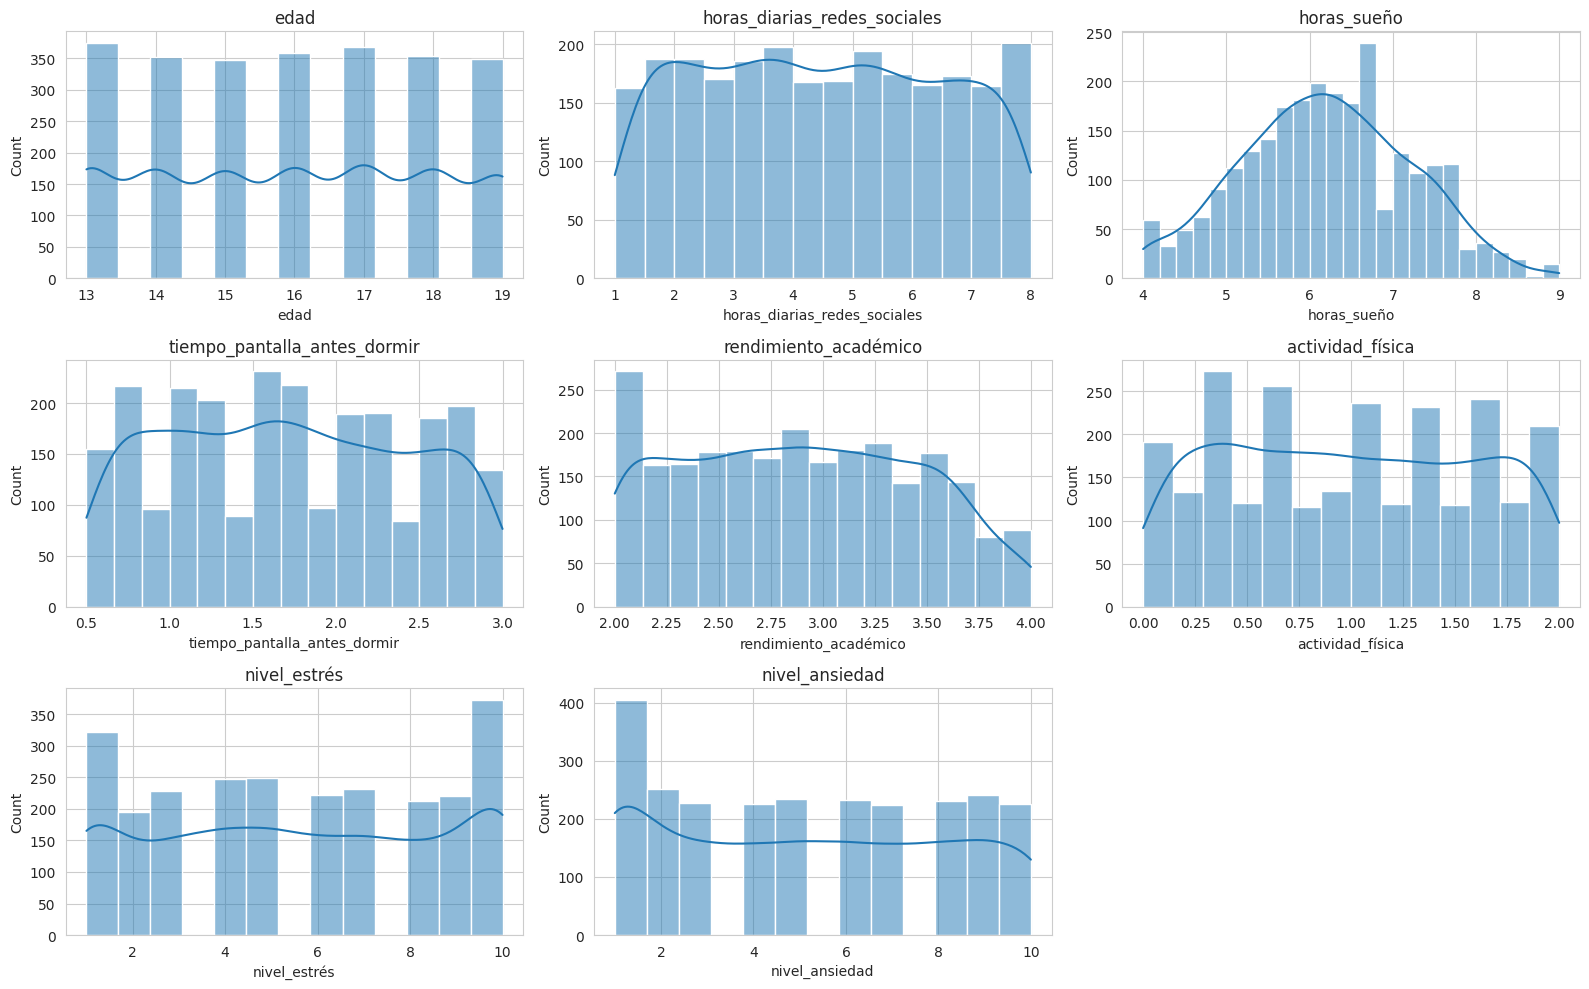

In [44]:
plt.figure(figsize=(16,10))

for i,col in enumerate(numericas,1):

    plt.subplot(3,3,i)

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

plt.tight_layout()
plt.show()

In [50]:
print("Resumen estadístico variables numéricas")
display(df[numericas].describe().T)

Resumen estadístico variables numéricas


,count,mean,std,min,25%,50%,75%,max
edad,2500.0,15.978000,2.003577,13.0,14.00,16.00,18.00,19.0
horas_diarias_redes_sociales,2500.0,4.458040,2.016930,1.0,2.70,4.40,6.20,8.0
horas_sueño,2500.0,6.192440,1.018734,4.0,5.50,6.20,6.90,9.0
tiempo_pantalla_antes_dormir,2500.0,1.714760,0.716636,0.5,1.10,1.70,2.30,3.0
rendimiento_académico,2500.0,2.890944,0.559553,2.0,2.42,2.88,3.34,4.0
actividad_física,2500.0,0.991760,0.586963,0.0,0.50,1.00,1.50,2.0
nivel_estrés,2500.0,5.596400,3.039013,1.0,3.00,6.00,8.00,10.0
nivel_ansiedad,2500.0,5.164800,3.002473,1.0,2.00,5.00,8.00,10.0


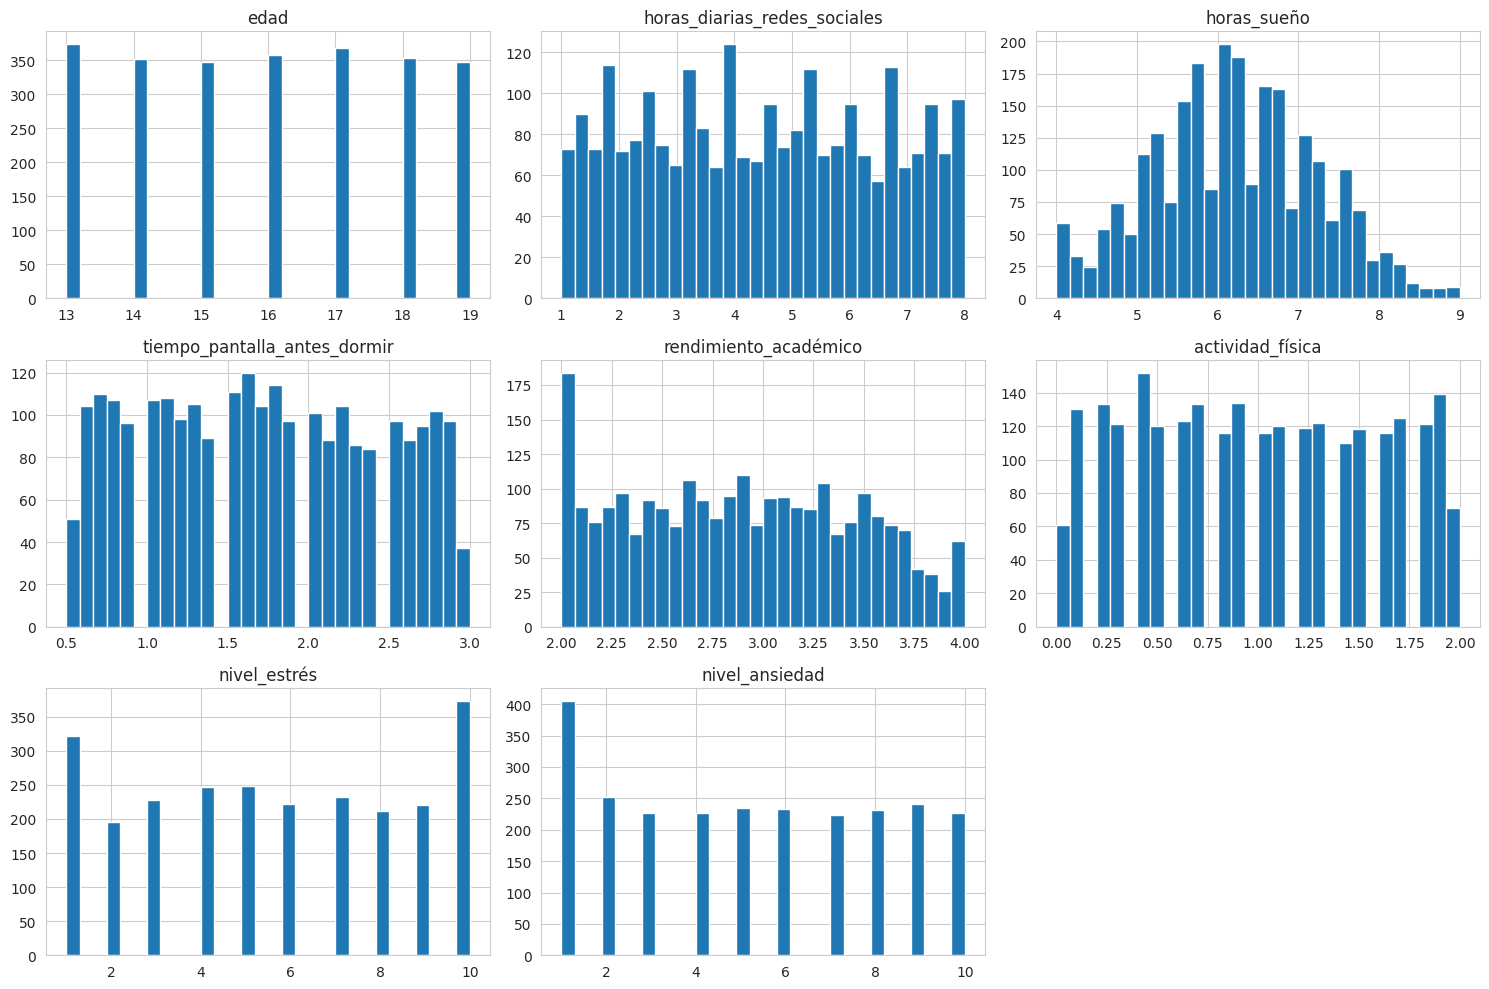

In [15]:
numericas = ['edad', 'horas_diarias_redes_sociales', 'horas_sueño', 'tiempo_pantalla_antes_dormir', 'rendimiento_académico', 'actividad_física', 'nivel_estrés', 'nivel_ansiedad']

df[numericas].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

Los histogramas permiten observar el comportamiento individual de las variables numéricas. En términos generales, las distribuciones muestran una adecuada variabilidad entre los registros, sin concentraciones excesivas en valores específicos. Destaca el uso intensivo de redes sociales, con varios jóvenes que superan las cinco horas diarias de utilización, mientras que las horas de sueño se concentran principalmente entre cinco y siete horas por noche. Asimismo, los niveles de estrés y ansiedad presentan una dispersión suficiente para identificar distintos perfiles dentro de la población analizada.

**Boxplots / Outliers**

Los diagramas de caja permitieron revisar la presencia de valores atípicos en las variables numéricas. Algunos valores extremos pueden observarse en variables asociadas a hábitos y bienestar, pero se mantienen dentro de rangos posibles para la población joven. Por ello, no deberían eliminarse automáticamente sin evaluar su impacto en el análisis posterior.

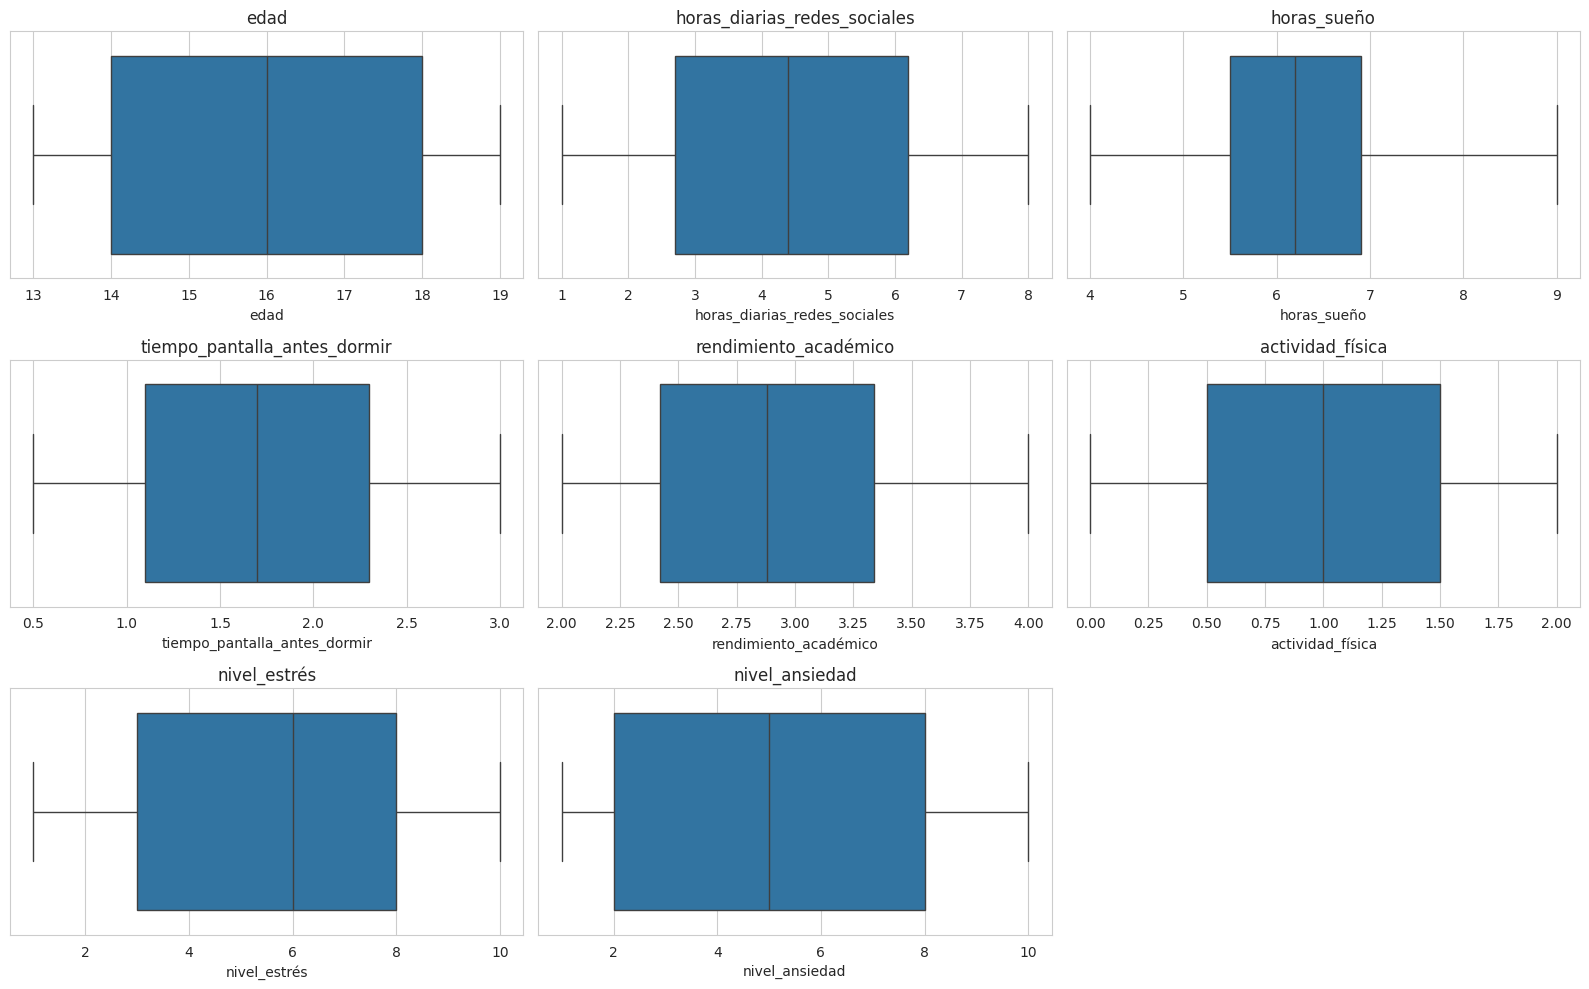

In [45]:
plt.figure(figsize=(16,10))

for i,col in enumerate(numericas,1):

    plt.subplot(3,3,i)

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

Los diagramas de caja permitieron identificar algunos valores extremos en variables relacionadas con hábitos de uso de redes sociales, horas de sueño y niveles de ansiedad. No obstante, estos registros permanecen dentro de rangos plausibles para la población adolescente estudiada, por lo que podrían representar comportamientos reales y no necesariamente errores de captura. Por esta razón, se recomienda mantenerlos durante las etapas iniciales del análisis.

**Distribución de la variable objetivo (riesgo_depresión)**

La distribución de la variable objetivo muestra que el riesgo bajo es la categoría más frecuente, seguida por riesgo medio y riesgo alto. Aunque existe una mayor presencia de casos de bajo riesgo, la distribución no presenta un desbalance severo, lo que resulta favorable para futuros modelos de clasificación.

In [18]:
df["riesgo_depresión"].value_counts()

,count
riesgo_depresión,
BAJO,1266
MEDIO,650
ALTO,584


In [19]:
df["riesgo_depresión"].value_counts(normalize=True)*100

,proportion
riesgo_depresión,
BAJO,50.64
MEDIO,26.00
ALTO,23.36


La distribución de la variable objetivo evidencia una mayor concentración de jóvenes clasificados en la categoría de riesgo bajo de depresión. Sin embargo, las categorías de riesgo medio y alto también presentan una representación importante dentro de la muestra. Esta distribución relativamente equilibrada resulta favorable para el desarrollo de modelos de clasificación, ya que disminuye la probabilidad de sesgos hacia una única categoría.

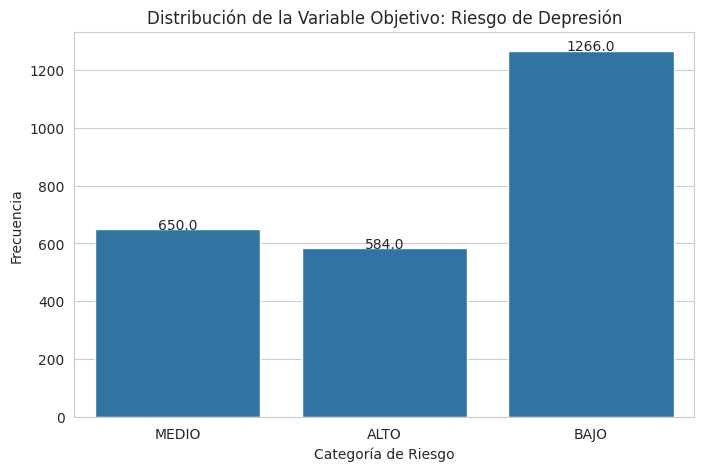

In [46]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='riesgo_depresión'
)

plt.title("Distribución de la Variable Objetivo: Riesgo de Depresión")
plt.xlabel("Categoría de Riesgo")
plt.ylabel("Frecuencia")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center'
    )

plt.show()

El análisis de la variable objetivo **riesgo_depresión** muestra que la categoría de riesgo bajo concentra la mayor cantidad de observaciones con 1.266 registros (50,64%), seguida por riesgo medio con 650 registros (26,0%) y riesgo alto con 584 registros (23,36%). La distribución de clases se considera relativamente equilibrada, ya que ninguna categoría presenta una representación excesivamente dominante. Por esta razón, no fue necesario aplicar técnicas de balanceo de clases antes del entrenamiento de los modelos de clasificación, permitiendo trabajar con la distribución original de los datos sin introducir modificaciones artificiales en el conjunto de entrenamiento.

**Matriz de correlación.**

La matriz de correlación permite observar la relación entre las variables numéricas. Este análisis ayuda a identificar qué características podrían tener mayor asociación con el riesgo de depresión y permite detectar posibles relaciones entre hábitos digitales, sueño, actividad física, estrés y ansiedad.

In [47]:
df_corr = df.copy()

le = LabelEncoder()

df_corr['riesgo_depresión'] = le.fit_transform(
    df_corr['riesgo_depresión']
)

In [48]:
corr = df_corr[numericas.tolist() + ['riesgo_depresión']].corr()

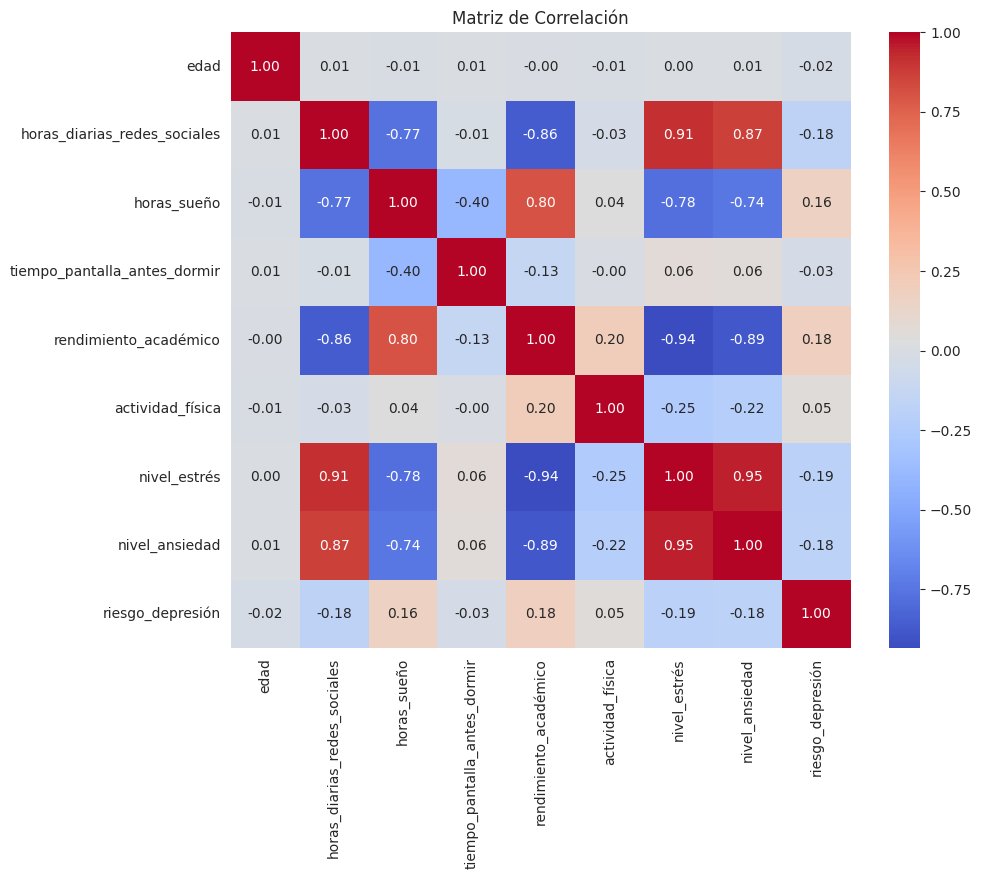

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación permite identificar la intensidad y dirección de las relaciones lineales entre las variables numéricas. Se observan asociaciones más relevantes entre los niveles de ansiedad, estrés y riesgo de depresión, lo que resulta coherente con la naturaleza del problema estudiado. Estas relaciones sugieren que dichas variables podrían desempeñar un papel importante en la capacidad predictiva de futuros modelos de clasificación.

# **Conclusión del Análisis Exploratorio de Datos (EDA)**

El análisis exploratorio realizado sobre el conjunto de datos de salud mental en jóvenes permitió obtener una comprensión integral de la estructura, calidad y comportamiento de las variables disponibles antes de la etapa de modelado. En primer lugar, se constató que el dataset posee 2.500 registros y 12 variables, combinando información demográfica, hábitos de uso de redes sociales, calidad del sueño, rendimiento académico, actividad física, interacción social e indicadores asociados al bienestar psicológico.

Desde la perspectiva de la calidad de los datos, se observó que el conjunto presenta una estructura consistente, sin registros duplicados y sin valores nulos en ninguna de sus variables, lo que reduce significativamente la necesidad de procesos complejos de limpieza o imputación. Asimismo, la revisión de las variables categóricas no evidenció inconsistencias de escritura, diferencias de formato ni categorías erróneas que requirieran corrección.

El análisis descriptivo mostró una distribución equilibrada en variables como edad, género y niveles de interacción social, mientras que variables relacionadas con hábitos de vida, como horas de sueño, tiempo de pantalla antes de dormir y actividad física, presentan una variabilidad suficiente para aportar información relevante al proceso de clasificación. Los histogramas permitieron observar que la mayoría de las variables numéricas presentan distribuciones razonables y coherentes con el contexto del estudio, sin concentraciones anómalas que sugieran problemas de captura de datos.

Por otra parte, los diagramas de caja permitieron identificar la presencia de algunos valores extremos en determinadas variables, especialmente aquellas asociadas a comportamientos individuales. Sin embargo, estos valores se encuentran dentro de rangos plausibles para la población analizada y podrían representar casos reales de jóvenes con hábitos o condiciones particulares, por lo que no se justifica su eliminación automática sin una evaluación adicional.

Respecto de la variable objetivo riesgo_depresión, se observó una distribución relativamente equilibrada entre las categorías bajo, medio y alto riesgo. Aunque la categoría de riesgo bajo presenta una mayor frecuencia, ninguna de las clases domina excesivamente el conjunto de datos, por lo que no se evidencian problemas severos de desbalance que requieran la aplicación de técnicas de sobremuestreo o submuestreo antes del entrenamiento de los modelos de clasificación.

En términos generales, el análisis exploratorio permite concluir que el dataset presenta una buena calidad, consistencia y representatividad para desarrollar modelos predictivos orientados a la clasificación del riesgo de depresión en jóvenes. Las características observadas sugieren que las variables incluidas poseen potencial explicativo suficiente para identificar patrones asociados al bienestar psicológico, constituyendo una base adecuada para las etapas posteriores de preparación de datos, transformación de variables y construcción de modelos de aprendizaje automático.